#PINNs for 1D Static Bar
The goal is to solve the Poisson problem for 1D static bar $$\nabla (EA \nabla u(x))+ p(x)=0,\ x\in {\rm int}(\Omega)$$
subject to $$ EA\nabla u(x)=F\ {\rm on}\ \Gamma_N $$ and $$u = g\ {\rm on}\ \Gamma_D.$$
Following a manufactured solution, we assume \begin{align*}&u(x)=1-\cos(3\pi x),\ x \in (0,\tfrac{2}{3}),\\
&EA(x)=1+x^2,\\
&p(x)=-\{6\pi x\sin(3\pi x) + 9\pi^2 (1+x^2)\cos(3\pi x)\},\\
&u(0)=0,\\
&EAu'(\tfrac{2}{3})=0. \end{align*}
This example is taken from the following reference:

*Hermann, L. et al. *Deep Learning in Computational Mechanics: An Introductory Course*, 2nd edition, Springer, 2025.

Installing `equinox`:

In [ ]:
!pip install equinox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.2/181.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.4 MB/s eta 0:00:00


Necessary imports:

In [ ]:
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import matplotlib.pyplot as plt

Let's first visualize the exact solution:

In [ ]:
def exactSol(x):
  u_exact = 1 - jnp.cos(3 * jnp.pi * x)
  return u_exact

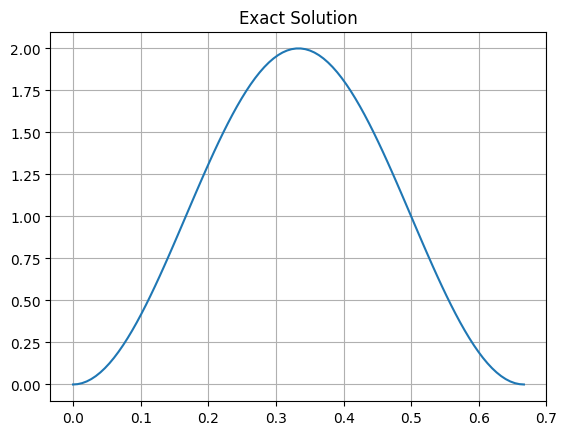

In [ ]:
x_plot = jnp.linspace(0, 2/3, 100)
u_plot = exactSol(x_plot)
plt.plot(x_plot, u_plot)
plt.grid()
plt.title("Exact Solution")
plt.show()

We define functions for the axial rigidity, $EA(x)$ and the distributed load, $p(x)$:

In [ ]:
def axial_rigidity(x):
  ea = 1 + x**2
  return ea

def distributed_load(x):
  pl = -6*jnp.pi*x*jnp.sin(3*jnp.pi*x) - 9*jnp.pi**2*(1+x**2)*jnp.cos(3*jnp.pi*x)
  return pl

A key for initialization:

In [ ]:
key = jax.random.PRNGKey(0)
key, init_key = jax.random.split(key)

We define our PINN as a multi-layer perceptron; that is, we approximate the solution by a trainable neural network, $u(x)\approx {\rm MLP}(x;\theta)$:

In [ ]:
pinn = eqx.nn.MLP(
    in_size="scalar",
    out_size="scalar",
    width_size=10,
    depth=3,
    activation=jax.nn.sigmoid,
    key=init_key
)

We define a function that returns the axial force $EAu'(x)$ based on the defined PINN:

In [ ]:
def axial_force(network, x):
  return axial_rigidity(x)*jax.grad(network)(x)

Residual:

In [ ]:
def ode_residual(network, x):
  r = jax.grad(axial_force, argnums=1)(network, x) + distributed_load(x)
  return r

Initial residual:

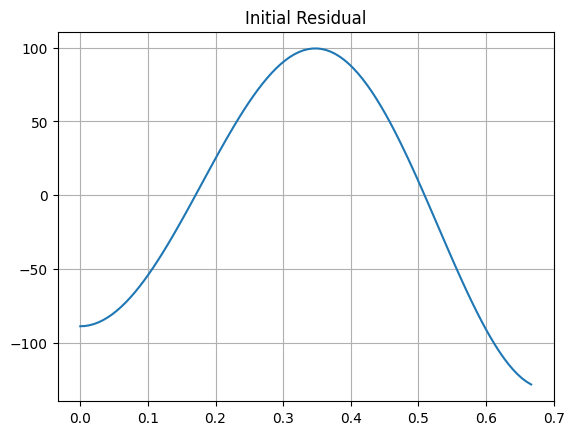

In [ ]:
init_res = jax.vmap(ode_residual, in_axes=(None, 0))(pinn, x_plot)
plt.plot(x_plot, init_res)
plt.grid()
plt.title("Initial Residual")
plt.show()

In [ ]:
init_bc_loss = 0.5 * (pinn(0.0)**2 + axial_force(pinn, 2.0/3)**2)
print(init_bc_loss)

2.7658454e-05


We generate collocation points:

In [ ]:
key, xkey = jax.random.split(key)
N_collocation = 40
x_collocation = jax.random.uniform(xkey, (N_collocation,), minval=0.0+1e-04, maxval=2.0/3-1e-04)

We now define the loss function. The loss comprises two terms: 1) ode residula and 2) boundary conditions residual.

In [ ]:
def pinn_loss(network):
  # Ode loss
  residue_at_collocation = jax.vmap(ode_residual, in_axes=(None,0))(network, x_collocation)
  ode_loss = 0.5 * jnp.mean(residue_at_collocation**2)

  # Boundary loss
  u_at_left_boundary = network(0.0)
  F_at_right_boundary = axial_force(network, 2.0/3)
  bc_loss = 0.5 * (u_at_left_boundary**2 + F_at_right_boundary**2)

  # Total loss
  lambda_bc = 10
  total_loss = ode_loss + lambda_bc * bc_loss
  return total_loss


In [ ]:
print(pinn_loss(pinn))

2834.1467


Setting up an optimizer:

In [ ]:
l_rate = 1e-02
N_epochs = 10_000

optimizer = optax.adam(l_rate)
opt_state = optimizer.init(eqx.filter(pinn, eqx.is_array))

We define a function that perform the model updating to be used during the training:

In [ ]:
@eqx.filter_jit
def model_update(network, state):
  loss, grad = eqx.filter_value_and_grad(pinn_loss)(network)
  updates, new_state = optimizer.update(grad, state)
  new_network = eqx.apply_updates(network, updates)
  return new_network, new_state, loss

Training loop:

In [ ]:
loss_history = []

for epoch in range(N_epochs):
  pinn, opt_state, loss = model_update(pinn, opt_state)
  loss_history.append(loss)
  if epoch % 1000 == 0:
    print(f"Epoch: {epoch}, Loss: {loss}")


Epoch: 0, Loss: 2834.146728515625
Epoch: 1000, Loss: 17.406591415405273
Epoch: 2000, Loss: 0.12339503318071365
Epoch: 3000, Loss: 0.0208768080919981
Epoch: 4000, Loss: 0.011677836067974567
Epoch: 5000, Loss: 0.006920123007148504
Epoch: 6000, Loss: 0.004633851815015078
Epoch: 7000, Loss: 0.0030565140768885612
Epoch: 8000, Loss: 0.001926230383105576
Epoch: 9000, Loss: 0.0012748625595122576


Text(0.5, 1.0, 'Loss History')

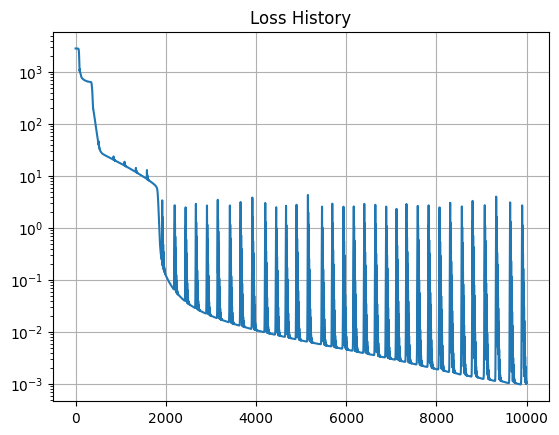

In [ ]:
plt.plot(loss_history)
plt.yscale("log")
plt.grid()
plt.title("Loss History")

Let's visualize the PINN solution:

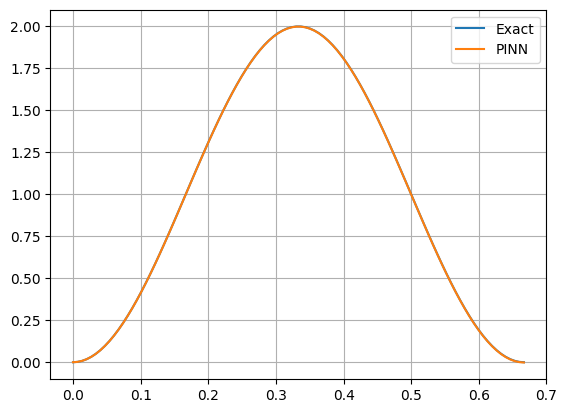

In [ ]:
x_test = jnp.linspace(0, 2.0/3, 100)
u_true = exactSol(x_test)
u_pred = jax.vmap(pinn)(x_test)

plt.plot(x_test, u_true, label="Exact")
plt.plot(x_test, u_pred, label="PINN")
plt.grid()
plt.legend()

Let us now calculate the strain across the bar, $\epsilon(x) = \frac{du}{dx}(x)$:

Text(0.5, 0, 'x')

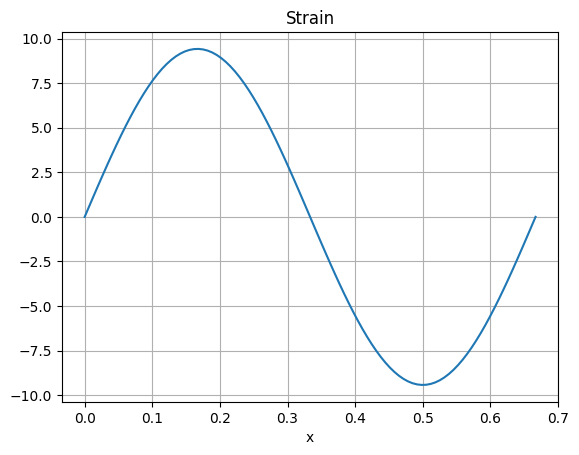

In [ ]:
strain = jax.vmap(jax.grad(pinn))(x_test)
plt.plot(x_test, strain)
plt.grid()
plt.title("Strain")
plt.xlabel("x")